# EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('/content/Global_Cybersecurity_Threats_2015-2024.csv')
df

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [ ]:
df.shape

(3000, 10)

In [ ]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [ ]:
missing_values = df.isnull().sum()
missing_values

,0
Country,0
Year,0
Attack Type,0
Target Industry,0
Financial Loss (in Million $),0
Number of Affected Users,0
Attack Source,0
Security Vulnerability Type,0
Defense Mechanism Used,0
Incident Resolution Time (in Hours),0


In [ ]:
# Distribución de valores en variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns
value_counts_categorical = {col: df[col].value_counts() for col in categorical_columns}
value_counts_categorical

{'Country': Country
 UK           321
 Brazil       310
 India        308
 Japan        305
 France       305
 Australia    297
 Russia       295
 Germany      291
 USA          287
 China        281
 Name: count, dtype: int64,
 'Attack Type': Attack Type
 DDoS                 531
 Phishing             529
 SQL Injection        503
 Ransomware           493
 Malware              485
 Man-in-the-Middle    459
 Name: count, dtype: int64,
 'Target Industry': Target Industry
 IT                    478
 Banking               445
 Healthcare            429
 Retail                423
 Education             419
 Government            403
 Telecommunications    403
 Name: count, dtype: int64,
 'Attack Source': Attack Source
 Nation-state    794
 Unknown         768
 Insider         752
 Hacker Group    686
 Name: count, dtype: int64,
 'Security Vulnerability Type': Security Vulnerability Type
 Zero-day              785
 Social Engineering    747
 Unpatched Software    738
 Weak Passwords       

In [ ]:
# Manejo de valores atípicos en pérdidas financieras y número de afectados
columns_to_check = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']
outliers_info = {}

for col in columns_to_check:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Contar valores atípicos antes de eliminarlos
        num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_info[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Number of Outliers": num_outliers
        }

outliers_info


{'Financial Loss (in Million $)': {'Q1': np.float64(25.7575),
  'Q3': np.float64(75.63),
  'IQR': np.float64(49.872499999999995),
  'Lower Bound': np.float64(-49.05124999999999),
  'Upper Bound': np.float64(150.43874999999997),
  'Number of Outliers': np.int64(0)},
 'Number of Affected Users': {'Q1': np.float64(255805.25),
  'Q3': np.float64(758088.5),
  'IQR': np.float64(502283.25),
  'Lower Bound': np.float64(-497619.625),
  'Upper Bound': np.float64(1511513.375),
  'Number of Outliers': np.int64(0)},
 'Incident Resolution Time (in Hours)': {'Q1': np.float64(19.0),
  'Q3': np.float64(55.0),
  'IQR': np.float64(36.0),
  'Lower Bound': np.float64(-35.0),
  'Upper Bound': np.float64(109.0),
  'Number of Outliers': np.int64(0)}}

/tmp/ipython-input-3121718540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Year", palette="viridis")


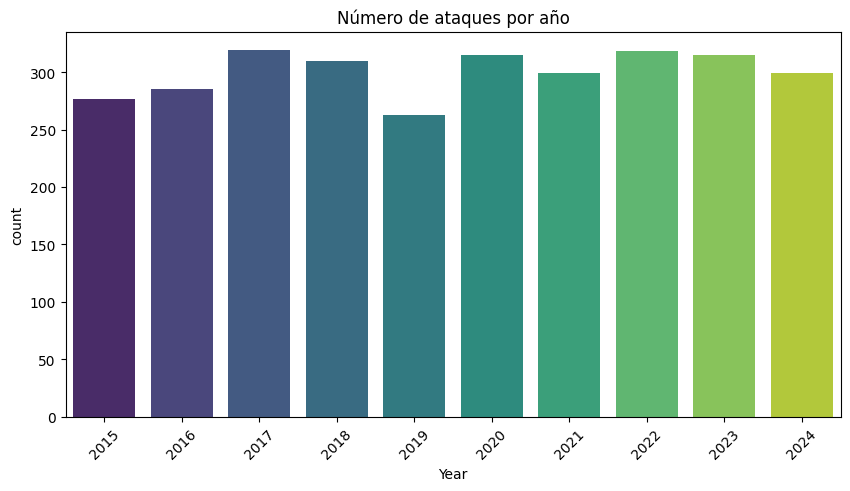

In [ ]:
# Gráfico de ataques por año
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Year", palette="viridis")
plt.title("Número de ataques por año")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-2080420364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target Industry", y="Financial Loss (in Million $)", palette="magma")


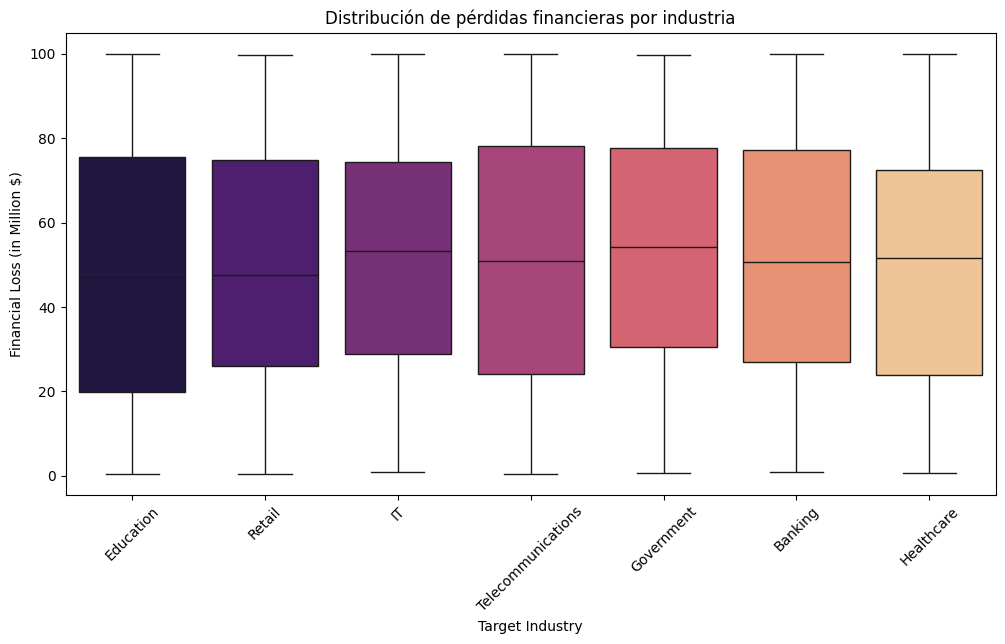

In [ ]:
# Gráfico de pérdidas financieras por industria
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Target Industry", y="Financial Loss (in Million $)", palette="magma")
plt.title("Distribución de pérdidas financieras por industria")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-2102984386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Attack Type", order=df["Attack Type"].value_counts().index, palette="coolwarm")


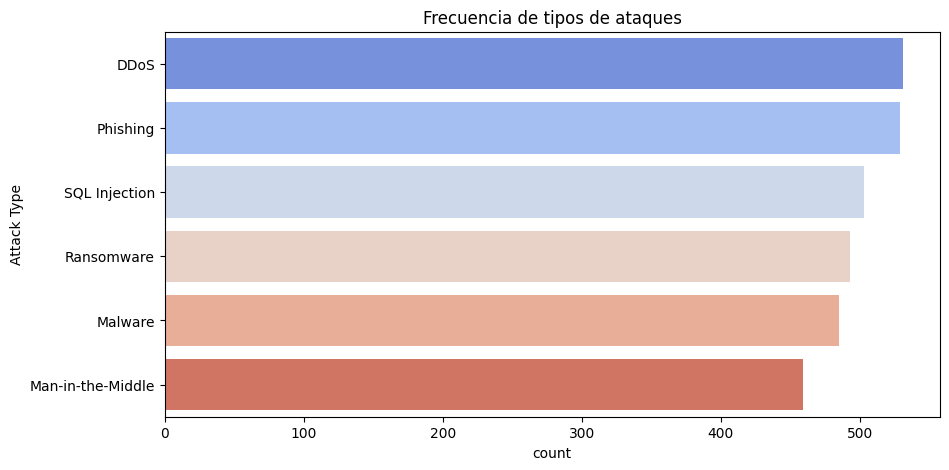

In [ ]:

# Gráfico de ataques por tipo
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="Attack Type", order=df["Attack Type"].value_counts().index, palette="coolwarm")
plt.title("Frecuencia de tipos de ataques")
plt.show()


/tmp/ipython-input-702814095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attack Type", y="Incident Resolution Time (in Hours)", palette="pastel")


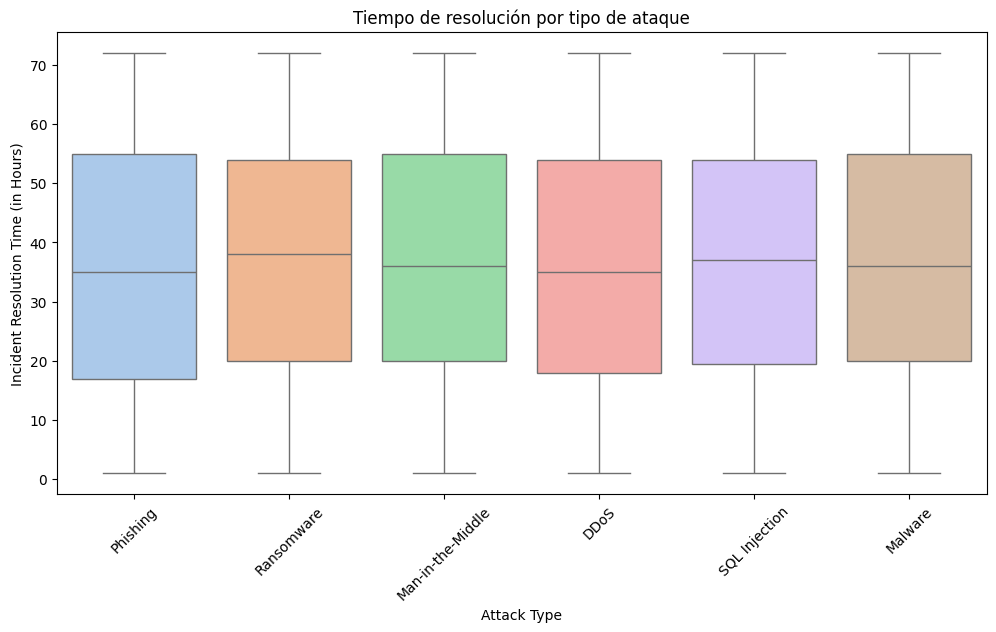

In [ ]:

# Gráfico de tiempo de resolución por tipo de ataque
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Attack Type", y="Incident Resolution Time (in Hours)", palette="pastel")
plt.title("Tiempo de resolución por tipo de ataque")
plt.xticks(rotation=45)
plt.show()

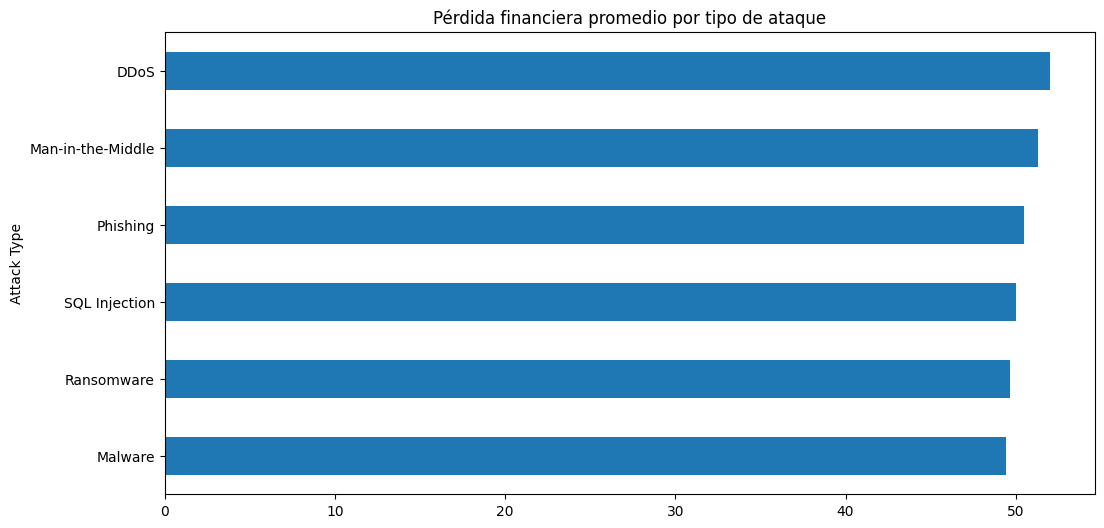

In [ ]:
# Pérdidas financieras por ataque
df.groupby('Attack Type')['Financial Loss (in Million $)'].mean().sort_values().plot(kind='barh', figsize=(12, 6))
plt.title("Pérdida financiera promedio por tipo de ataque")
plt.show()

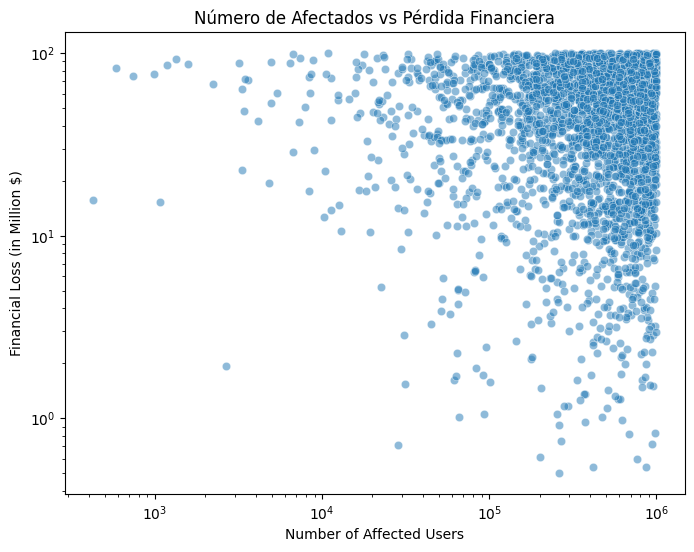

In [ ]:
# Relación entre número de afectados y pérdidas financieras
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Number of Affected Users'], y=df['Financial Loss (in Million $)'], alpha=0.5)
plt.title("Número de Afectados vs Pérdida Financiera")
plt.xscale("log")
plt.yscale("log")
plt.show()


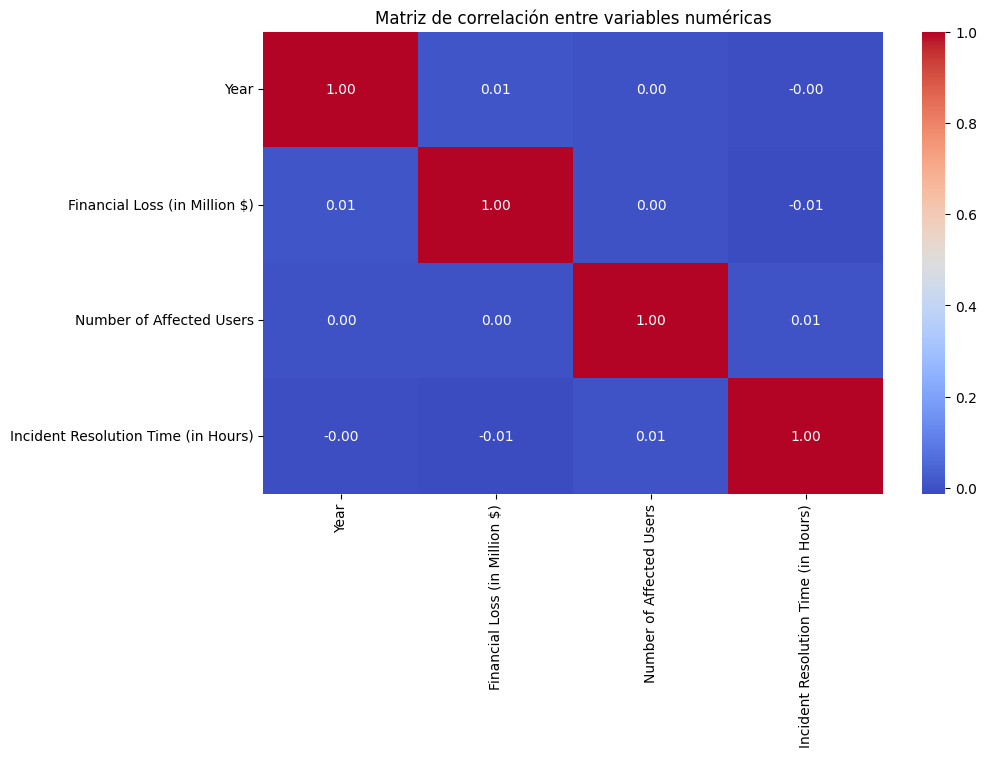

In [ ]:
# Filtrar solo las columnas numéricas para la matriz de correlación
numeric_cols = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


In [ ]:
# Creación de una nueva variable de riesgo relativo
df['Risk Score'] = df['Financial Loss (in Million $)'] / (df['Number of Affected Users'] + 1)
df['Risk Score']

,Risk Score
0,0.000104
1,0.000210
2,0.000064
3,0.000063
4,0.000092
...,...
2995,0.000270
2996,0.000034
2997,0.000045
2998,0.000085


In [ ]:
# Normalización del tiempo de resolución
df['Normalized Resolution Time'] = df['Incident Resolution Time (in Hours)'] / df.groupby('Attack Type')['Incident Resolution Time (in Hours)'].transform('mean')
df['Normalized Resolution Time']

,Normalized Resolution Time
0,1.754237
1,1.943423
2,0.542425
3,0.191605
4,1.844245
...,...
2995,1.423352
2996,0.704482
2997,0.812864
2998,0.243859


In [ ]:
# One-Hot Encoding de variables categóricas
df_encoded = pd.get_dummies(df, columns=['Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used'])
df_encoded

,Country,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Risk Score,Normalized Resolution Time,Attack Type_DDoS,Attack Type_Malware,Attack Type_Man-in-the-Middle,...,Attack Source_Unknown,Security Vulnerability Type_Social Engineering,Security Vulnerability Type_Unpatched Software,Security Vulnerability Type_Weak Passwords,Security Vulnerability Type_Zero-day,Defense Mechanism Used_AI-based Detection,Defense Mechanism Used_Antivirus,Defense Mechanism Used_Encryption,Defense Mechanism Used_Firewall,Defense Mechanism Used_VPN
0,China,2019,80.53,773169,63,0.000104,1.754237,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,China,2019,62.19,295961,71,0.000210,1.943423,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,India,2017,38.65,605895,20,0.000064,0.542425,False,False,True,...,False,False,False,True,False,False,False,False,False,True
3,UK,2024,41.44,659320,7,0.000063,0.191605,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,Germany,2018,74.41,810682,68,0.000092,1.844245,False,False,True,...,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,51.42,190694,52,0.000270,1.423352,False,False,False,...,True,True,False,False,False,False,False,False,True,False
2996,Brazil,2023,30.28,892843,26,0.000034,0.704482,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2997,Brazil,2017,32.97,734737,30,0.000045,0.812864,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2998,UK,2022,32.17,379954,9,0.000085,0.243859,False,False,False,...,False,False,True,False,False,False,False,False,True,False


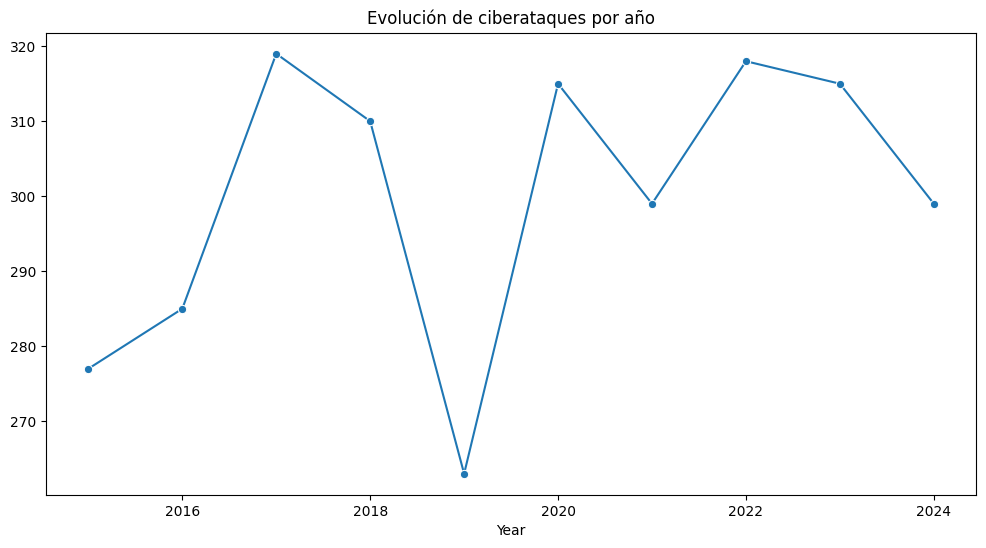

In [ ]:
# Evolución de ataques a lo largo del tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.groupby('Year').size(), marker='o', linestyle='-')
plt.title("Evolución de ciberataques por año")
plt.show()

/tmp/ipython-input-3259366719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Defense Mechanism Used', y='Incident Resolution Time (in Hours)', palette='coolwarm')


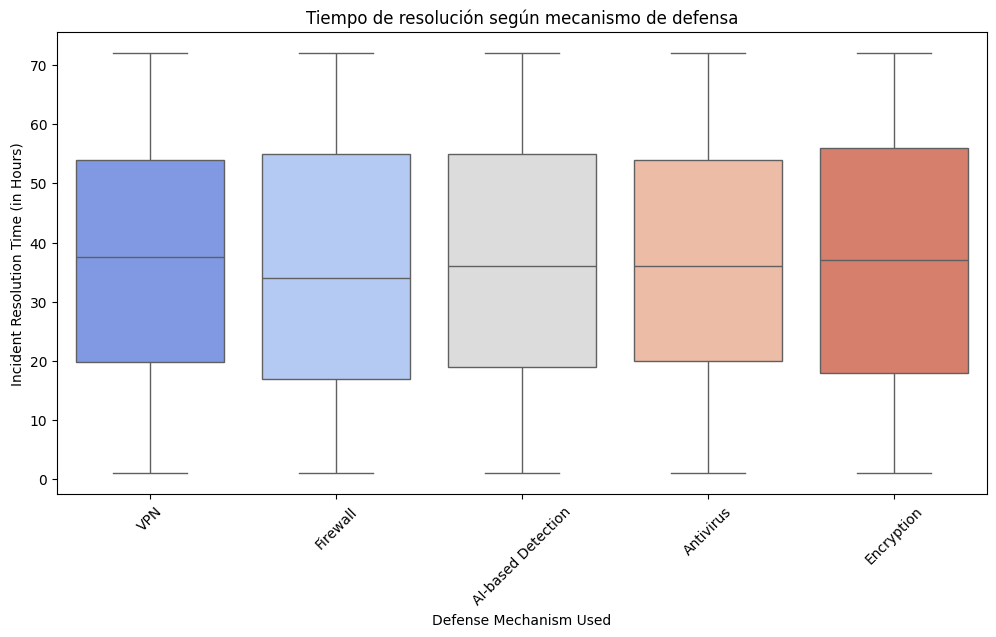

In [ ]:
# Efectividad de mecanismos de defensa
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Defense Mechanism Used', y='Incident Resolution Time (in Hours)', palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Tiempo de resolución según mecanismo de defensa")
plt.show()

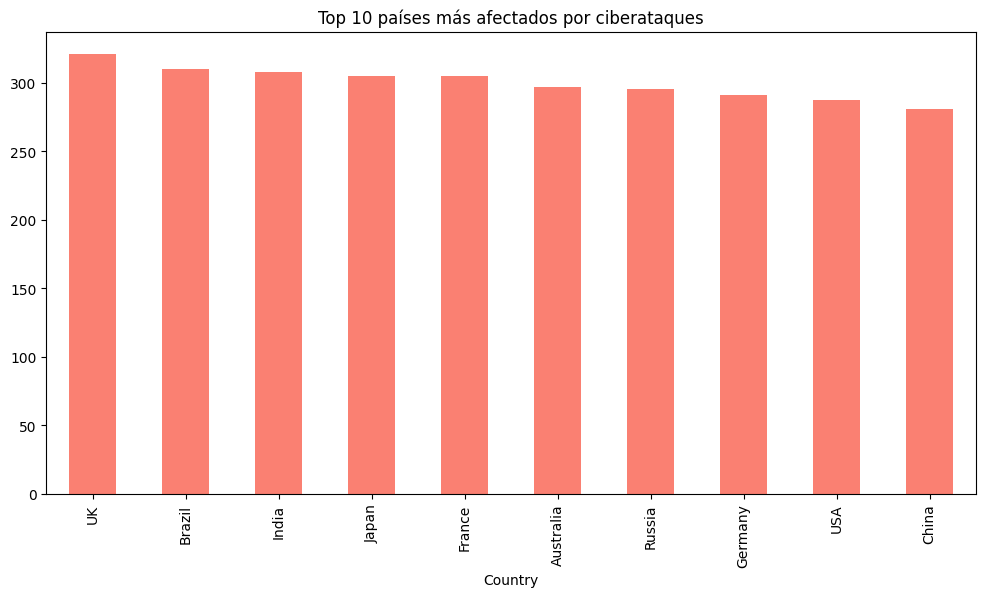

In [ ]:
# Países más afectados
plt.figure(figsize=(12, 6))
df['Country'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 países más afectados por ciberataques")
plt.show()

# Modelo Supervisado - Luz Angela

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
# Crear una copia para trabajar
df_model = df.copy()
# Codificamos columnas categóricas
categorical_cols = df_model.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Seleccionar solo columnas numéricas
features = df_model.select_dtypes(include=['int64', 'float64'])

Modelo Supervisado - Random Forest (para clasificación)


In [ ]:
from scipy.stats import chi2_contingency
for col in ['Country', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']:
    contingency_table = pd.crosstab(df[col], df['Attack Type'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")

Country: chi2=41.61, p-value=0.6163
Target Industry: chi2=38.46, p-value=0.1384
Attack Source: chi2=9.71, p-value=0.8377
Security Vulnerability Type: chi2=23.18, p-value=0.0805
Defense Mechanism Used: chi2=21.75, p-value=0.3542


In [ ]:
print(df_model.isnull().sum())
df_model = df_model.dropna()  # O imputa valores faltantes

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
Risk Score                             0
Normalized Resolution Time             0
dtype: int64


In [ ]:
# Paso 2: Crear la columna 'IsAnomaly' en df_model
# Usaremos los percentiles 5 y 95 para marcar valores extremos como anomalías

# Definir umbrales por variable usando df_model
loss_threshold_high = df_model['Financial Loss (in Million $)'].quantile(0.95)
loss_threshold_low = df_model['Financial Loss (in Million $)'].quantile(0.05)

users_threshold_high = df_model['Number of Affected Users'].quantile(0.95)
users_threshold_low = df_model['Number of Affected Users'].quantile(0.05)

time_threshold_high = df_model['Incident Resolution Time (in Hours)'].quantile(0.95)
time_threshold_low = df_model['Incident Resolution Time (in Hours)'].quantile(0.05)

# Paso 3: Crear la columna binaria 'IsAnomaly' en df_model
df_model['IsAnomaly'] = (
    (df_model['Financial Loss (in Million $)'] > loss_threshold_high) |
    (df_model['Financial Loss (in Million $)'] < loss_threshold_low) |
    (df_model['Number of Affected Users'] > users_threshold_high) |
    (df_model['Number of Affected Users'] < users_threshold_low) |
    (df_model['Incident Resolution Time (in Hours)'] > time_threshold_high) |
    (df_model['Incident Resolution Time (in Hours)'] < time_threshold_low)
).astype(int)

# Paso 4: Mostrar distribución de anomalías
anomaly_counts = df_model['IsAnomaly'].value_counts()

# Mostrar las primeras filas de df_model con la nueva columna
print("Distribución de anomalías:")
print(anomaly_counts)

print("Primeras filas del DataFrame con la columna 'IsAnomaly' y conteo de anomalías:")
df_model.head()


Distribución de anomalías:
IsAnomaly
0    2245
1     755
Name: count, dtype: int64
Primeras filas del DataFrame con la columna 'IsAnomaly' y conteo de anomalías:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Risk Score,Normalized Resolution Time,IsAnomaly
0,2,2019,3,1,80.53,773169,0,1,4,63,0.000104,1.754237,0
1,2,2019,4,5,62.19,295961,0,1,3,71,0.000210,1.943423,1
2,5,2017,2,4,38.65,605895,0,2,4,20,0.000064,0.542425,0
3,8,2024,4,6,41.44,659320,2,0,0,7,0.000063,0.191605,0
4,4,2018,2,4,74.41,810682,1,0,4,68,0.000092,1.844245,0


In [ ]:
print(df_model.head(1))  # Muestra la primera fila del DataFrame


   Country  Year  Attack Type  Target Industry  Financial Loss (in Million $)  \
0        2  2019            3                1                          80.53   

   Number of Affected Users  Attack Source  Security Vulnerability Type  \
0                    773169              0                            1   

   Defense Mechanism Used  Incident Resolution Time (in Hours)  Risk Score  \
0                       4                                   63    0.000104   

   Normalized Resolution Time  IsAnomaly  
0                    1.754237          0  


In [ ]:
print(df_model.dtypes)  # Verifica los tipos de las columnas


Country                                  int64
Year                                     int64
Attack Type                              int64
Target Industry                          int64
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                            int64
Security Vulnerability Type              int64
Defense Mechanism Used                   int64
Incident Resolution Time (in Hours)      int64
Risk Score                             float64
Normalized Resolution Time             float64
IsAnomaly                                int64
dtype: object


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Selección de características
features = ['Country', 'Year', 'Attack Type', 'Target Industry',
            'Financial Loss (in Million $)', 'Number of Affected Users',
            'Attack Source', 'Security Vulnerability Type',
            'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']
X = df_model[features]
y = df_model['IsAnomaly']

# Manejo de desbalance de clases (SMOTE)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Ajuste del modelo para evitar sobreajuste
model_rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=10, min_samples_leaf=5, class_weight='balanced', max_features='sqrt', random_state=42)
model_rf.fit(X_train, y_train)

# Evaluación
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Validación cruzada
cv_scores = cross_val_score(model_rf, X_res, y_res, cv=10, scoring='accuracy')
print(cv_scores)
print("Mean CV Accuracy: ", cv_scores.mean())


              precision    recall  f1-score   support

           0       0.82      0.99      0.89       477
           1       0.99      0.75      0.85       421

    accuracy                           0.88       898
   macro avg       0.90      0.87      0.87       898
weighted avg       0.90      0.88      0.87       898

[1.         1.         0.99554566 0.88641425 0.79955457 0.79732739
 0.79955457 0.83073497 0.81514477 0.79510022]
Mean CV Accuracy:  0.8719376391982182


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')
print(cv_scores)
print("Mean CV Accuracy: ", cv_scores.mean())


[0.99833333 0.99666667 0.99833333 0.99833333 0.99833333]
Mean CV Accuracy:  0.9979999999999999


In [ ]:
df_encoded = pd.get_dummies(df_model[features])
df_encoded['IsAnomaly'] = df_model['IsAnomaly']
corr = df_encoded.corr()['IsAnomaly'].sort_values(ascending=False)
print(corr)

IsAnomaly                              1.000000
Incident Resolution Time (in Hours)    0.018173
Attack Type                            0.012162
Defense Mechanism Used                 0.011535
Country                                0.007817
Financial Loss (in Million $)          0.006268
Number of Affected Users              -0.005944
Attack Source                         -0.007478
Target Industry                       -0.007788
Security Vulnerability Type           -0.010791
Year                                  -0.010914
Name: IsAnomaly, dtype: float64


In [ ]:
y_series = pd.Series(y)
print(y_series.value_counts())


IsAnomaly
0    2245
1     755
Name: count, dtype: int64


Matriz de Confusión

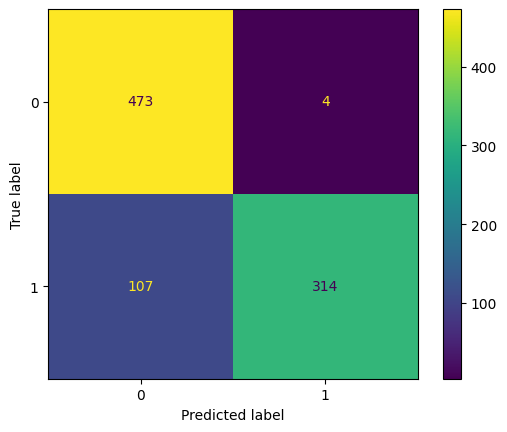

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


Curva ROC y AUC

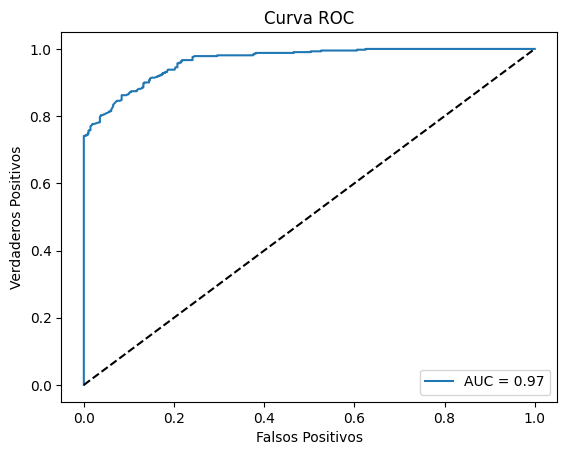

In [ ]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curva ROC")
plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.legend()
plt.show()


Curva Precision-Recall

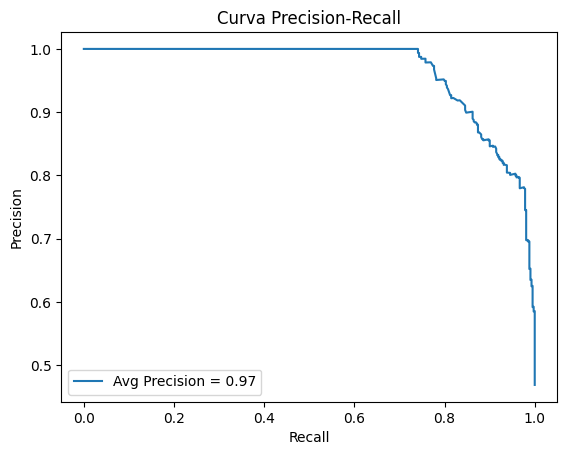

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f'Avg Precision = {avg_precision:.2f}')
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


Importancia de Características

In [ ]:
importances = model_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))


                               Feature  Importance
5             Number of Affected Users    0.415128
4        Financial Loss (in Million $)    0.262119
9  Incident Resolution Time (in Hours)    0.156121
6                        Attack Source    0.050247
7          Security Vulnerability Type    0.039422
8               Defense Mechanism Used    0.022935
3                      Target Industry    0.017513
2                          Attack Type    0.017433
0                              Country    0.009724
1                                 Year    0.009358


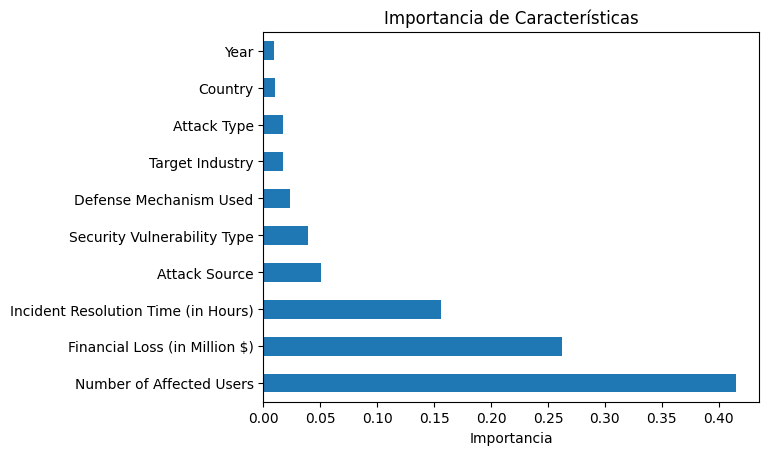

In [ ]:
importances = model_rf.feature_importances_
feat_importances = pd.Series(importances, index=features)
feat_importances.nlargest(10).plot(kind='barh', title="Importancia de Características")
plt.xlabel("Importancia")
plt.show()


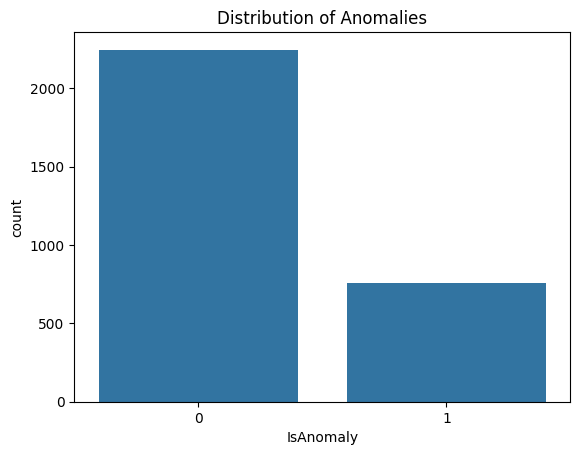

In [ ]:
sns.countplot(x='IsAnomaly', data=df_encoded)
plt.title('Distribution of Anomalies')
plt.show()


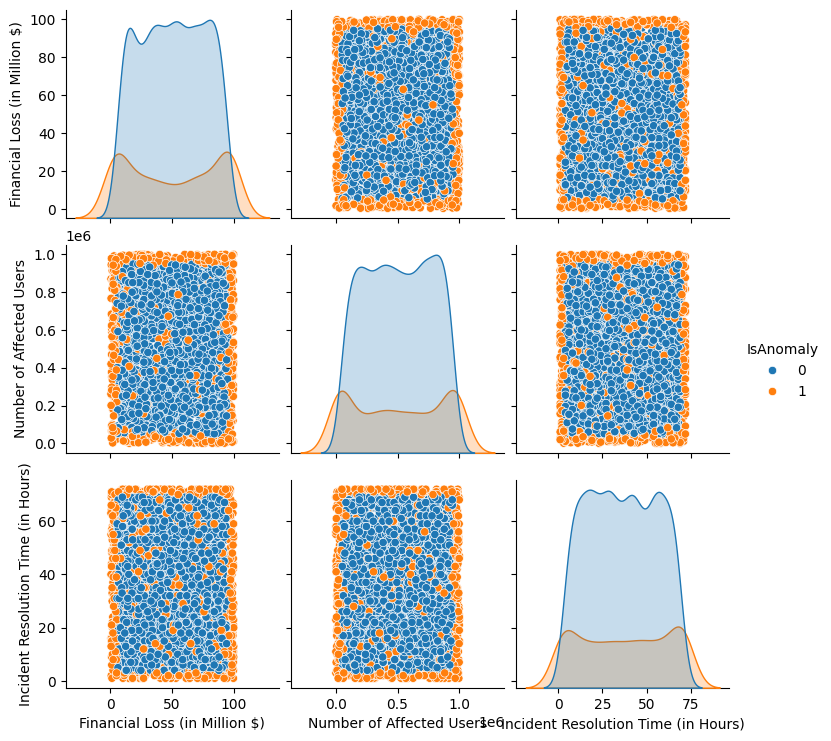

In [ ]:
sns.pairplot(df_encoded, vars=['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)'], hue='IsAnomaly')
plt.show()


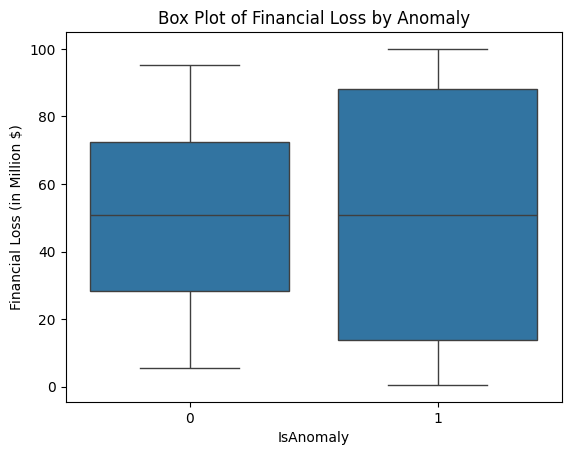

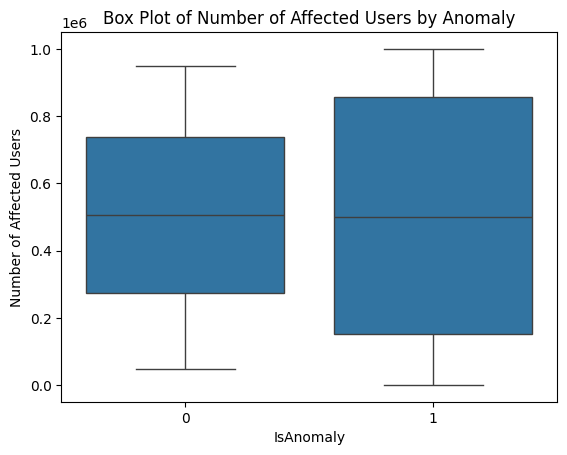

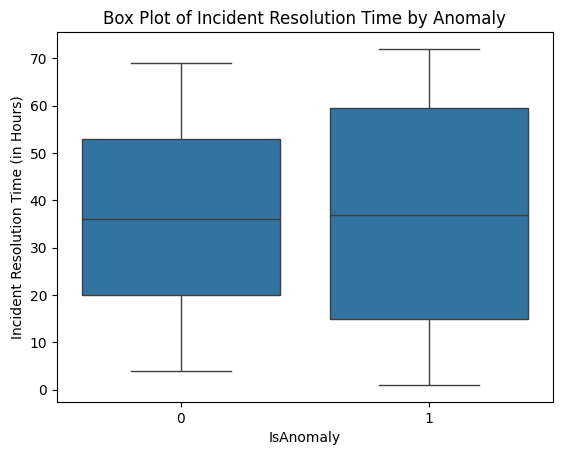

In [ ]:
sns.boxplot(x='IsAnomaly', y='Financial Loss (in Million $)', data=df_encoded)
plt.title('Box Plot of Financial Loss by Anomaly')
plt.show()

sns.boxplot(x='IsAnomaly', y='Number of Affected Users', data=df_encoded)
plt.title('Box Plot of Number of Affected Users by Anomaly')
plt.show()

sns.boxplot(x='IsAnomaly', y='Incident Resolution Time (in Hours)', data=df_encoded)
plt.title('Box Plot of Incident Resolution Time by Anomaly')
plt.show()


Modelo RNN

> Añadir blockquote



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
import tensorflow as tf

# Preprocesamiento
df = df_model.copy()

# Codifica variables categóricas
categorical_cols = ['Country', 'Attack Type', 'Target Industry', 'Attack Source',
                    'Security Vulnerability Type', 'Defense Mechanism Used']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Escala variables numéricas
scaler = MinMaxScaler()
numerical_cols = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)', 'Year']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Selección de características
features = ['Country', 'Year', 'Attack Type', 'Target Industry',
            'Financial Loss (in Million $)', 'Number of Affected Users',
            'Attack Source', 'Security Vulnerability Type',
            'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']
X = df[features].values
y_full = df['IsAnomaly'].values

# División 80/20 sin mezclar (útil para series temporales)
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train, y_test = train_test_split(y_full, test_size=0.2, shuffle=False)

# Crear secuencias para RNN
def create_sequences(data, labels, time_steps=10):
    seq_data = []
    seq_labels = []
    for i in range(len(data) - time_steps):
        seq_data.append(data[i:i + time_steps])
        seq_labels.append(labels[i + time_steps])
    return np.array(seq_data), np.array(seq_labels)

TIME_STEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)

# Definición del modelo autoencoder
n_features = X_train_seq.shape[2]

inputs = Input(shape=(TIME_STEPS, n_features))
encoded = LSTM(64, activation='relu')(inputs)
decoded = RepeatVector(TIME_STEPS)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Entrenamiento
history = autoencoder.fit(X_train_seq, X_train_seq,
                          epochs=20,
                          batch_size=32,
                          validation_split=0.1,
                          shuffle=False)

# Predicción sobre conjunto de prueba
reconstructions = autoencoder.predict(X_test_seq)
mse = np.mean(np.power(X_test_seq - reconstructions, 2), axis=(1, 2))

# Umbral de decisión (percentil 95)
threshold = np.percentile(mse, 95)
y_pred = (mse > threshold).astype(int)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 10)         │           650 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 4.1816 - val_loss: 1.8816
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.9335 - val_loss: 1.8114
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.8659 - val_loss: 1.7620
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 1.8177 - val_loss: 1.7369
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.7874 - val_loss: 1.7086
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.7513 - val_loss: 1.6661
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.7082 - val_loss: 1.6447
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.6657 - val_loss: 1.6256
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.6256 - val_loss: 1.5574
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.5711 - val_loss: 1.5155
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.5292 - val_loss: 1.4940
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.

In [ ]:
# Métricas de desempeño
print("Accuracy:", accuracy_score(y_test_seq, y_pred))
print("Precision:", precision_score(y_test_seq, y_pred))
print("Recall:", recall_score(y_test_seq, y_pred))
print("F1-score:", f1_score(y_test_seq, y_pred))
print("Matriz de Confusión:")
print(confusion_matrix(y_test_seq, y_pred))


Accuracy: 0.7186440677966102
Precision: 0.26666666666666666
Recall: 0.05263157894736842
F1-score: 0.08791208791208792
Matriz de Confusión:
[[416  22]
 [144   8]]


In [ ]:
# Índices donde se detectaron anomalías en las secuencias
anomaly_indices = np.where(y_pred == 1)[0]

# Calcular el punto inicial del conjunto de prueba con secuencias
start_index = len(X_train) + TIME_STEPS
end_index = start_index + len(y_test_seq)

# Subconjunto del DataFrame alineado con y_test_seq
df_test_seq = df.iloc[start_index:end_index].copy()

# Obtener solo las anomalías detectadas
df_anomalies = df_test_seq.iloc[anomaly_indices]

print("\nAnomalías detectadas:")
df_anomalies




Anomalías detectadas:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Risk Score,Normalized Resolution Time,IsAnomaly
2434,1,0.666667,5,5,0.008242,0.564298,2,2,3,0.000000,0.000002,0.027095,1
2435,0,0.222222,2,5,0.477133,0.036385,1,1,0,0.887324,0.001304,1.735760,1
2445,8,0.555556,0,5,0.698864,0.971807,2,2,3,0.042254,0.000072,0.112084,1
2448,7,0.888889,0,6,0.570409,0.114805,3,1,2,0.577465,0.000497,1.176887,0
2489,1,0.777778,2,1,0.916575,0.581068,1,0,4,0.929577,0.000158,1.817124,0
2517,0,0.111111,4,3,0.469193,0.509908,3,0,0,0.943662,0.000093,1.861307,0
2521,3,0.333333,4,2,0.023017,0.443656,0,2,1,0.535211,0.000006,1.067514,1
2522,6,0.222222,0,4,0.273997,0.825195,1,2,2,0.197183,0.000034,0.420317,0
2523,6,0.111111,2,5,0.585687,0.172058,2,0,0,0.704225,0.000341,1.383184,0
2524,4,0.777778,0,6,0.517137,0.920157,0,2,1,0.774648,0.000056,1.569182,0


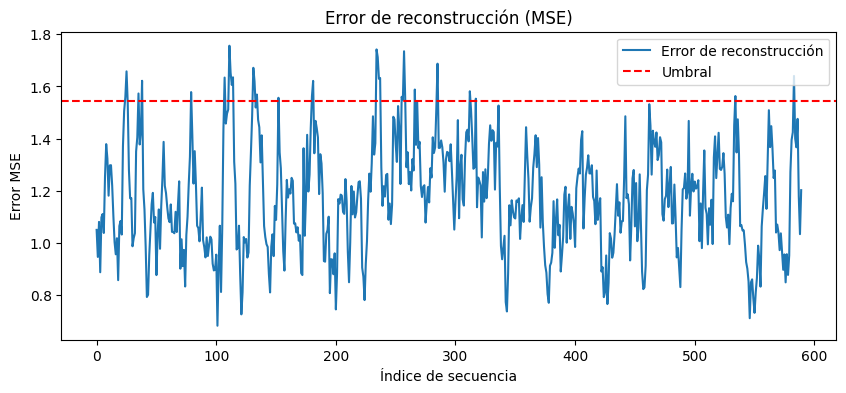

In [ ]:
# Visualización del error
plt.figure(figsize=(10, 4))
plt.plot(mse, label='Error de reconstrucción')
plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral')
plt.title('Error de reconstrucción (MSE)')
plt.xlabel('Índice de secuencia')
plt.ylabel('Error MSE')
plt.legend()
plt.show()



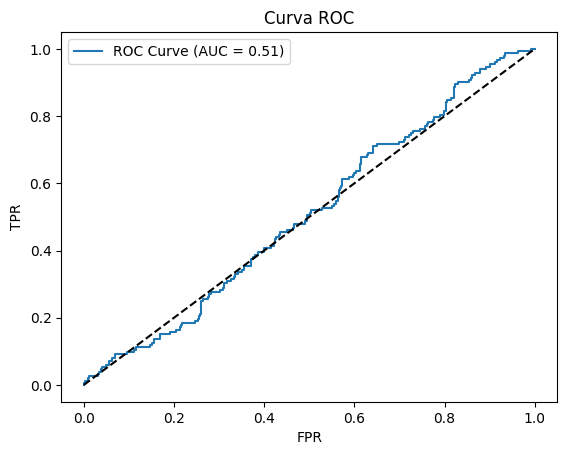

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test_seq, mse)
auc = roc_auc_score(y_test_seq, mse)
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

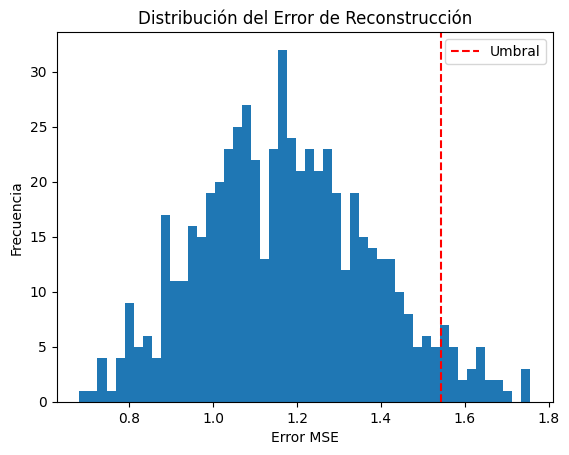

In [ ]:
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r', linestyle='--', label='Umbral')
plt.title('Distribución del Error de Reconstrucción')
plt.xlabel('Error MSE')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Isolation Forest (Detección No Supervisada) - Isabella


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [ ]:
# Crear una copia para trabajar
df_model = df.copy()
# Codificamos columnas categóricas
categorical_cols = df_model.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Seleccionar solo columnas numéricas
features = df_model.select_dtypes(include=['int64', 'float64'])

In [ ]:
df_model

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Risk Score,Normalized Resolution Time,IsAnomaly
0,2,0.444444,3,1,0.804402,0.773355,0,1,4,0.873239,0.000104,1.754237,0
1,2,0.444444,4,5,0.620062,0.295770,0,1,3,0.985915,0.000210,1.943423,1
2,5,0.222222,2,4,0.383456,0.605949,0,2,4,0.267606,0.000064,0.542425,0
3,8,1.000000,4,6,0.411499,0.659416,2,0,0,0.084507,0.000063,0.191605,0
4,4,0.333333,2,4,0.742889,0.810898,1,0,4,0.943662,0.000092,1.844245,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,8,0.666667,4,2,0.511810,0.190420,3,0,3,0.718310,0.000270,1.423352,0
2996,1,0.888889,5,6,0.299327,0.893124,0,3,4,0.352113,0.000034,0.704482,0
2997,1,0.222222,5,4,0.326364,0.734893,2,2,0,0.408451,0.000045,0.812864,0
2998,8,0.777778,5,4,0.318323,0.379830,1,1,3,0.112676,0.000085,0.243859,0


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   int64  
 1   Year                                 3000 non-null   float64
 2   Attack Type                          3000 non-null   int64  
 3   Target Industry                      3000 non-null   int64  
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   float64
 6   Attack Source                        3000 non-null   int64  
 7   Security Vulnerability Type          3000 non-null   int64  
 8   Defense Mechanism Used               3000 non-null   int64  
 9   Incident Resolution Time (in Hours)  3000 non-null   float64
 10  Risk Score                           3000 non-null   float64
 11  Normalized Resolution Time    

In [ ]:
# 1. Importar bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler # Recomendado para escalar
import matplotlib.pyplot as plt           # Para gráficos (opcional)
import seaborn as sns                     # Para gráficos (opcional)


# --- Verificación inicial (asegúrate de que df_model existe y tiene datos) ---
if 'df_model' not in locals() or not isinstance(df_model, pd.DataFrame) or df_model.empty:
    raise ValueError("El DataFrame 'df_model' no está definido, no es un DataFrame de pandas o está vacío.")
else:
    print("DataFrame 'df_model' cargado correctamente.")
    print(f"Dimensiones: {df_model.shape}")
    # print(df_model.info()) # Descomenta si quieres volver a ver la info

DataFrame 'df_model' cargado correctamente.
Dimensiones: (3000, 13)


In [ ]:
# 2. Preparación de los Datos
# Seleccionar todas las columnas para usarlas como características,
# ya que todas son numéricas y potencialmente relevantes para detectar anomalías.
features = df_model.columns.tolist()
print(f"\nCaracterísticas a utilizar: {features}")

# Extraer los datos como un array de NumPy
X = df_model[features].values

# (Recomendado) Escalar los datos:
# Aunque Isolation Forest no lo requiere estrictamente, escalar las características
# a una media de 0 y desviación estándar de 1 (StandardScaler) puede mejorar
# el rendimiento, especialmente si las características tienen rangos muy diferentes.
print("\nEscalando características con StandardScaler...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos escalados.")


Características a utilizar: ['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)', 'Risk Score', 'Normalized Resolution Time', 'IsAnomaly']

Escalando características con StandardScaler...
Datos escalados.


In [ ]:
# 3. Configurar y Entrenar el Modelo Isolation Forest
print("\nConfigurando y entrenando el modelo Isolation Forest...")

# Parámetros clave:
# - n_estimators: Número de árboles. 100 es un buen punto de partida.
# - contamination: Proporción estimada de anomalías en tus datos.
#                  Este es el parámetro MÁS IMPORTANTE para ajustar.
#                  'auto' es una opción, pero a menudo es mejor poner un valor
#                  explícito si tienes alguna idea (ej. 0.01 para 1%, 0.05 para 5%).
#                  ¡Experimenta con este valor! Empezaremos con 0.05 (5%) como ejemplo.
# - max_samples: Número de muestras para entrenar cada árbol. 'auto' suele funcionar bien.
# - random_state: Para que los resultados sean reproducibles.
# - n_jobs: -1 para usar todos los núcleos de CPU disponibles (acelera el entrenamiento).

contamination_rate = 0.05 # ¡AJUSTA ESTE VALOR SEGÚN SEA NECESARIO!

iso_forest_model = IsolationForest(n_estimators=100,
                                   contamination=contamination_rate,
                                   max_samples='auto',
                                   random_state=42,
                                   n_jobs=-1)

# Entrenar el modelo con los datos escalados
iso_forest_model.fit(X_scaled)
print("Modelo entrenado con éxito.")


Configurando y entrenando el modelo Isolation Forest...
Modelo entrenado con éxito.


In [ ]:
# 4. Realizar Predicciones y Obtener Puntuaciones
print("\nRealizando predicciones...")
# .predict() devuelve: 1 para inlier (normal), -1 para outlier (anomalía)
predictions = iso_forest_model.predict(X_scaled)

# .decision_function() devuelve la puntuación de anomalía cruda.
# Puntuaciones más bajas indican mayor probabilidad de ser anomalía.
# El umbral para la predicción (-1 o 1) se basa en 'contamination'.
anomaly_scores = iso_forest_model.decision_function(X_scaled)
print("Predicciones y puntuaciones obtenidas.")


Realizando predicciones...
Predicciones y puntuaciones obtenidas.



Resultados del Análisis:
Número total de registros: 3000
Número de anomalías detectadas: 150 (5.00%)
(Basado en una tasa de contaminación configurada de 5.0%)

Top 10 filas detectadas como anomalías (las más anómalas primero):
      Country      Year  Attack Type  Target Industry  \
1637        8  0.111111            0                6   
577         9  1.000000            0                5   
2217        4  0.000000            5                2   
1672        0  1.000000            0                3   
2502        4  0.888889            2                0   
2723        0  0.111111            3                1   
1503        5  0.666667            1                6   
2228        6  0.555556            0                1   
282         8  0.222222            5                0   
2300        9  0.222222            5                2   

      Financial Loss (in Million $)  Number of Affected Users  Attack Source  \
1637                       0.743793                  0.000311   

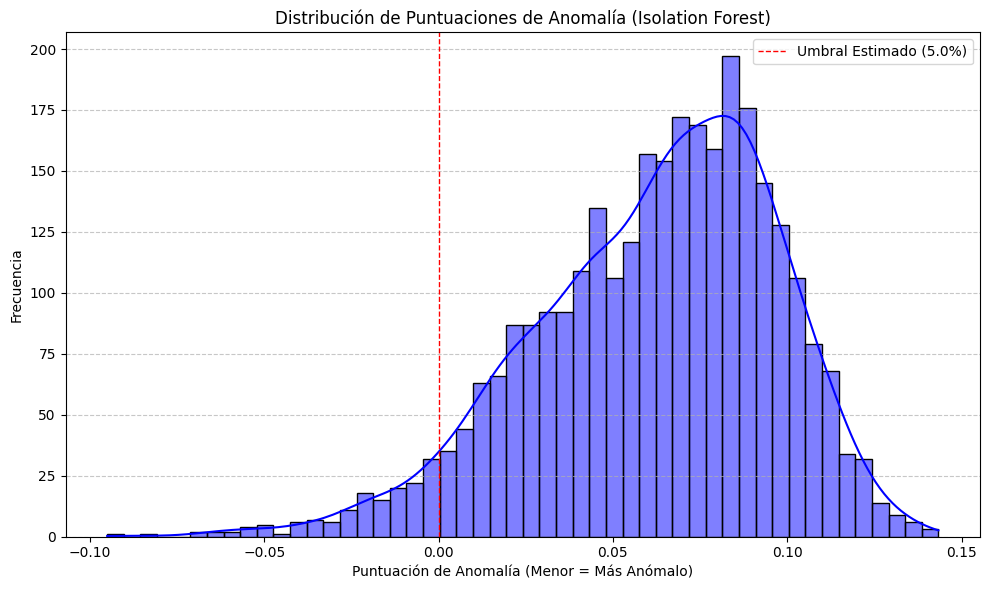

In [ ]:
# 5. Analizar los Resultados
# Añadir las predicciones y puntuaciones al DataFrame original para facilitar el análisis
df_model['iforest_score'] = anomaly_scores
df_model['iforest_anomaly'] = predictions # 1 = normal, -1 = anomalía

# Contar el número de anomalías detectadas
num_anomalies = (df_model['iforest_anomaly'] == -1).sum()
total_rows = len(df_model)
print(f"\nResultados del Análisis:")
print(f"Número total de registros: {total_rows}")
print(f"Número de anomalías detectadas: {num_anomalies} ({num_anomalies/total_rows*100:.2f}%)")
print(f"(Basado en una tasa de contaminación configurada de {contamination_rate*100:.1f}%)")

# Mostrar las filas identificadas como anomalías
# Ordenarlas por puntuación para ver las más anómalas primero
anomalies_detected = df_model[df_model['iforest_anomaly'] == -1].sort_values(by='iforest_score')

print("\nTop 10 filas detectadas como anomalías (las más anómalas primero):")
print(anomalies_detected.head(10))

# (Opcional) Mostrar algunas filas normales para comparar
# print("\nEjemplo de 5 filas detectadas como normales:")
# print(df_model[df_model['iforest_anomaly'] == 1].head())

# (Opcional) Visualizar la distribución de las puntuaciones de anomalía
print("\nGenerando gráfico de distribución de puntuaciones (si seaborn está instalado)...")
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_model['iforest_score'], bins=50, kde=True, color='blue')
    plt.title('Distribución de Puntuaciones de Anomalía (Isolation Forest)')
    plt.xlabel('Puntuación de Anomalía (Menor = Más Anómalo)')
    plt.ylabel('Frecuencia')

    # Calcular y dibujar el umbral aproximado basado en la contaminación
    threshold = np.percentile(df_model['iforest_score'], contamination_rate * 100)
    plt.axvline(threshold, color='red', linestyle='dashed', linewidth=1,
                label=f'Umbral Estimado ({contamination_rate*100:.1f}%)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Seaborn no está instalado. Omiteindo gráfico. Instala con: pip install seaborn matplotlib")
except Exception as e:
    print(f"No se pudo generar el gráfico: {e}")

In [ ]:
import pickle
import joblib # Para comparar, joblib es similar pero a veces mejor para sklearn

# --- Asumiendo que ya entrenaste tu modelo: iso_forest_model ---

# --- Usando Pickle ---
nombre_archivo_pkl = 'isolation_forest_model.pkl'
print(f"\nGuardando el modelo entrenado en '{nombre_archivo_pkl}' usando pickle...")
with open(nombre_archivo_pkl, 'wb') as file: # 'wb' es write binary
    pickle.dump(iso_forest_model, file)
print("Modelo guardado con pickle.")

# Para cargarlo después con pickle:
# print(f"\nCargando el modelo desde '{nombre_archivo_pkl}' usando pickle...")
# with open(nombre_archivo_pkl, 'rb') as file: # 'rb' es read binary
#     modelo_cargado_pkl = pickle.load(file)
# print("Modelo cargado con pickle.")

# --- Usando Joblib (como referencia, lo que mostré antes) ---
nombre_archivo_joblib = 'isolation_forest_model.joblib'
print(f"\nGuardando el modelo entrenado en '{nombre_archivo_joblib}' usando joblib...")
joblib.dump(iso_forest_model, nombre_archivo_joblib)
print("Modelo guardado con joblib.")

# Para cargarlo después con joblib:
# modelo_cargado_joblib = joblib.load(nombre_archivo_joblib)


Guardando el modelo entrenado en 'isolation_forest_model.pkl' usando pickle...
Modelo guardado con pickle.

Guardando el modelo entrenado en 'isolation_forest_model.joblib' usando joblib...
Modelo guardado con joblib.


# Isolation Forest + PCA

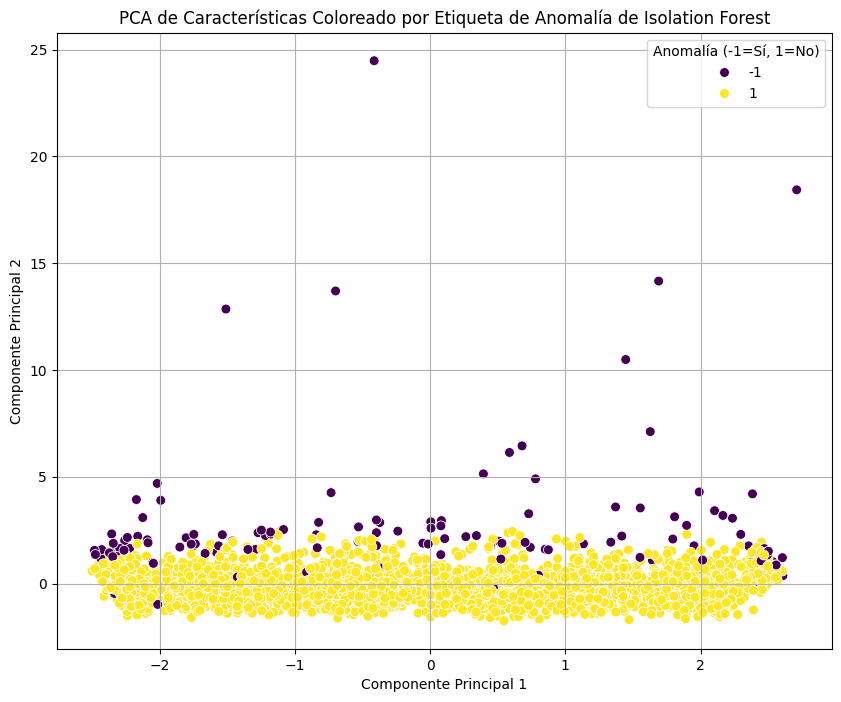

Varianza explicada por el Componente Principal 1: 0.15412780724081387
Varianza explicada por el Componente Principal 2: 0.095830670183763
Varianza total explicada por los 2 componentes: 0.24995847742457689


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Asumimos que df_model ya está cargado como mostraste.
# Si no, cárgalo aquí:
# df_model = pd.read_csv('tu_archivo.csv') # Reemplaza 'tu_archivo.csv'

# 1. Separar las características de las columnas de resultados de IForest
# Seleccionamos todas las columnas EXCEPTO las de iforest
features = df_model.drop(columns=['iforest_score', 'iforest_anomaly'])

# 2. Escalar las características
# PCA es sensible a la escala, así que es crucial escalar los datos
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Aplicar PCA
# Reducimos a 2 componentes principales para la visualización
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# 4. Crear un nuevo DataFrame con los componentes principales y la etiqueta de anomalía
pca_df = pd.DataFrame(data = principal_components,
                      columns = ['principal_component_1', 'principal_component_2'])

# Añadir la etiqueta de anomalía original de Isolation Forest
pca_df['iforest_anomaly'] = df_model['iforest_anomaly']

# 5. Visualizar
# Graficar los componentes principales coloreados por la etiqueta de anomalía
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2',
                hue='iforest_anomaly', # Colorea por la etiqueta de anomalía (-1 o 1)
                palette='viridis',     # Esquema de color
                s=50,                  # Tamaño de los puntos
                data=pca_df)

plt.title('PCA de Características Coloreado por Etiqueta de Anomalía de Isolation Forest')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Anomalía (-1=Sí, 1=No)')
plt.grid(True)
plt.show()

# Opcional: Ver cuánta varianza explican los componentes principales
print("Varianza explicada por el Componente Principal 1:", pca.explained_variance_ratio_[0])
print("Varianza explicada por el Componente Principal 2:", pca.explained_variance_ratio_[1])
print("Varianza total explicada por los 2 componentes:", pca.explained_variance_ratio_.sum())

# Autoencoders -Isabella

Dimensiones del DataFrame original: (3000, 15)
Columnas del DataFrame: ['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)', 'Risk Score', 'Normalized Resolution Time', 'IsAnomaly', 'iforest_score', 'iforest_anomaly']

Dimensiones del DataFrame de características: (3000, 12)

Datos escalados. Forma: (3000, 12)
Forma de datos de entrenamiento: (2400, 12)
Forma de datos de validación: (600, 12)

Modelo Autoencoder definido:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo Autoencoder...
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.9505 - val_loss: 0.9733
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8657 - val_loss: 0.9025
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8788 - val_loss: 0.8198
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7304 - val_loss: 0.7841
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6822 - val_loss: 0.7373
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6862 - val_loss: 0.7102
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6295 - val_loss: 0.6902
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6228 - val_loss: 0.6657
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6165 - val_loss: 0.6424
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5894 - val_loss: 0.6209
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5621 - val_loss: 0.6065
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━

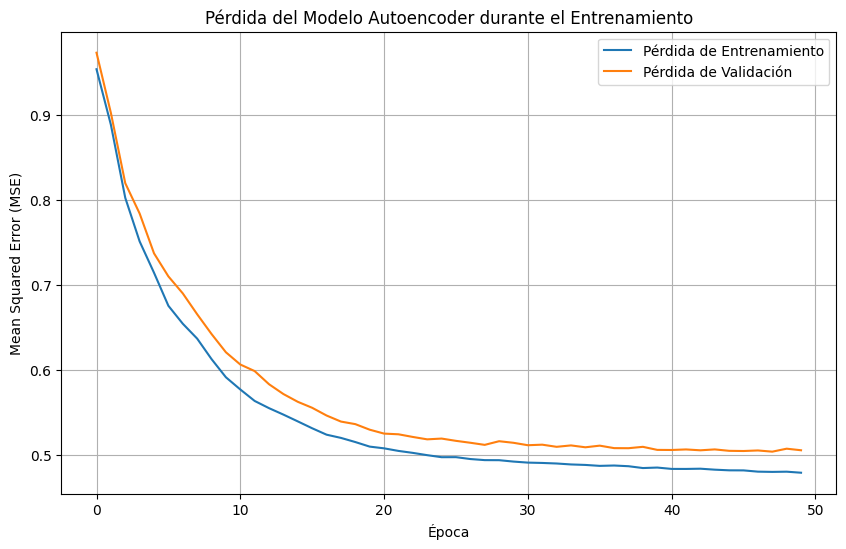

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Puntuaciones de error de reconstrucción añadidas a df_model.
Primeras 5 puntuaciones: 0    0.344360
1    0.464202
2    0.349574
3    0.768456
4    0.294114
Name: autoencoder_reconstruction_error, dtype: float64


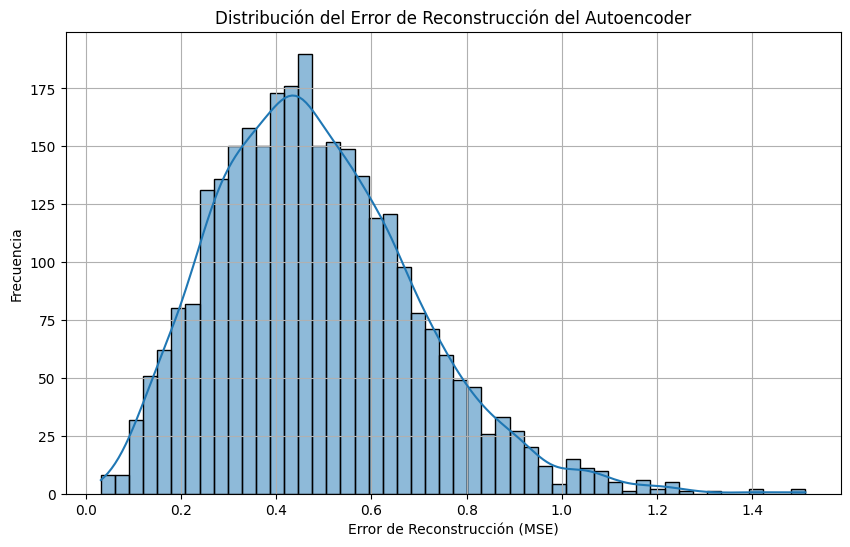


Umbral de Error de Reconstrucción (95º percentil): 0.8643

Número de anomalías detectadas por el Autoencoder: 150
Proporción de anomalías: 5.00%

DataFrame con columnas de Autoencoder:
   autoencoder_reconstruction_error  autoencoder_anomaly
0                          0.344360                    1
1                          0.464202                    1
2                          0.349574                    1
3                          0.768456                    1
4                          0.294114                    1

Modelo Autoencoder guardado en: autoencoder_anomaly_model/autoencoder.h5
Scaler guardado en: autoencoder_anomaly_model/scaler.gz


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # Opcional pero buena práctica
import matplotlib.pyplot as plt
import os # Para guardar el modelo

# --- 1. Preparación de Datos ---

# Asumimos que df_model ya está cargado.
# Si no, cárgalo aquí:
# df_model = pd.read_csv('tu_archivo.csv') # Reemplaza 'tu_archivo.csv'

print("Dimensiones del DataFrame original:", df_model.shape)
print("Columnas del DataFrame:", df_model.columns.tolist())

# Seleccionar las columnas de características para el Autoencoder.
# Excluimos las columnas de resultados de Isolation Forest si ya existen
# y cualquier otra columna que no sea una característica de entrada.
# Basado en tu info, las primeras 12 columnas son las features.
feature_columns = [
    'Country', 'Year', 'Attack Type', 'Target Industry',
    'Financial Loss (in Million $)', 'Number of Affected Users',
    'Attack Source', 'Security Vulnerability Type',
    'Defense Mechanism Used', 'Incident Resolution Time (in Hours)',
    'Risk Score', 'Normalized Resolution Time'
]

# Asegurarse de que las columnas existen en el DataFrame
selected_features_df = df_model[feature_columns]

print("\nDimensiones del DataFrame de características:", selected_features_df.shape)

# Escalar las características
# Los Autoencoders (como la mayoría de las redes neuronales) se benefician enormemente del escalado.
# StandardScaler es una buena opción.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(selected_features_df)

print("\nDatos escalados. Forma:", scaled_features.shape)

# Opcional: Dividir datos en entrenamiento y validación
# Aunque es detección no supervisada y a menudo se entrena en todos los datos,
# una división ayuda a monitorear el sobreajuste. Entrenaremos asumiendo que la mayoría
# de los datos son "normales".
X_train, X_val = train_test_split(scaled_features, test_size=0.2, random_state=42)

print(f"Forma de datos de entrenamiento: {X_train.shape}")
print(f"Forma de datos de validación: {X_val.shape}")

# --- 2. Definición del Modelo Autoencoder ---

# El Autoencoder consiste en un Encoder y un Decoder.
# El Encoder comprime los datos a una representación latente (el bottleneck).
# El Decoder reconstruye los datos a partir de la representación latente.

input_dim = scaled_features.shape[1] # Número de características de entrada
latent_dim = 5 # Dimensión del espacio latente (bottleneck). Puedes experimentar con este valor.

# Definir el Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation='relu')(input_layer) # Primera capa oculta del encoder
encoder = Dense(8, activation='relu')(encoder)     # Segunda capa oculta del encoder
latent_view = Dense(latent_dim, activation='relu')(encoder) # Capa del cuello de botella (bottleneck)

# Definir el Decoder
decoder = Dense(8, activation='relu')(latent_view)     # Primera capa oculta del decoder
decoder = Dense(16, activation='relu')(decoder)    # Segunda capa oculta del decoder
output_layer = Dense(input_dim, activation='linear')(decoder) # Capa de salida (reconstrucción)

# Crear el modelo Autoencoder completo
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compilar el modelo
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())

print("\nModelo Autoencoder definido:")
autoencoder.summary()

# --- 3. Entrenamiento del Modelo ---

print("\nEntrenando el modelo Autoencoder...")

# Entrenar el modelo. Entrenamos en los datos escalados.
# Los datos de entrada (X) y salida (y) son los mismos para un autoencoder.
history = autoencoder.fit(X_train, X_train,
                          epochs=50, # Número de épocas. Experimenta con este valor.
                          batch_size=32, # Tamaño del batch. Experimenta con este valor.
                          shuffle=True, # Barajar los datos en cada época
                          validation_data=(X_val, X_val),
                          verbose=1) # 1 muestra la barra de progreso

print("Entrenamiento completado.")

# Opcional: Graficar la pérdida de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida del Modelo Autoencoder durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()


# --- 4. Obtener Puntuaciones de Anomalía (Error de Reconstrucción) ---

# Predecir la reconstrucción para todos los datos escalados (entrenamiento + validación)
reconstructions = autoencoder.predict(scaled_features)

# Calcular el error de reconstrucción para cada muestra
# Usamos Mean Squared Error (MSE) entre la entrada original y la reconstrucción
mse = np.mean(np.square(scaled_features - reconstructions), axis=1)

# Añadir las puntuaciones de error de reconstrucción al DataFrame original
df_model['autoencoder_reconstruction_error'] = mse

print("\nPuntuaciones de error de reconstrucción añadidas a df_model.")
print("Primeras 5 puntuaciones:", df_model['autoencoder_reconstruction_error'].head())

# --- 5. Establecer un Umbral y Clasificar Anomalías ---

# Para clasificar una muestra como anomalía, necesitamos un umbral en el error de reconstrucción.
# Un método común es usar un percentil de los errores de reconstrucción.
# Las muestras con un error por encima del umbral se consideran anomalías.

# Visualizar la distribución del error de reconstrucción para ayudar a elegir el umbral
plt.figure(figsize=(10, 6))
sns.histplot(df_model['autoencoder_reconstruction_error'], bins=50, kde=True)
plt.title('Distribución del Error de Reconstrucción del Autoencoder')
plt.xlabel('Error de Reconstrucción (MSE)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Calcular un umbral basado en un percentil (ej. 95º percentil)
# Esto significa que el 5% de los puntos con mayor error serán marcados como anomalías.
# Puedes ajustar el percentil según la proporción esperada de anomalías o visualización.
threshold = np.percentile(df_model['autoencoder_reconstruction_error'], 95) # Percentil 95

print(f"\nUmbral de Error de Reconstrucción (95º percentil): {threshold:.4f}")

# Clasificar las muestras como normales (1) o anomalías (-1) basado en el umbral
df_model['autoencoder_anomaly'] = [
    -1 if error > threshold else 1 for error in df_model['autoencoder_reconstruction_error']
]

# Contar el número de anomalías detectadas
num_anomalies = df_model[df_model['autoencoder_anomaly'] == -1].shape[0]

print(f"\nNúmero de anomalías detectadas por el Autoencoder: {num_anomalies}")
print(f"Proporción de anomalías: {num_anomalies / df_model.shape[0] * 100:.2f}%")

print("\nDataFrame con columnas de Autoencoder:")
print(df_model[['autoencoder_reconstruction_error', 'autoencoder_anomaly']].head())


# --- 6. Guardar el Modelo y el Scaler ---

# Guardar el modelo Autoencoder entrenado para su uso futuro
model_dir = 'autoencoder_anomaly_model'
os.makedirs(model_dir, exist_ok=True)
autoencoder.save(os.path.join(model_dir, 'autoencoder.h5')) # Guarda en formato HDF5 o SavedModel

print(f"\nModelo Autoencoder guardado en: {model_dir}/autoencoder.h5")

# También es importante guardar el scaler, ya que los nuevos datos para predicción
# deberán ser escalados de la misma manera.
import joblib # Usaremos joblib para guardar el scaler

scaler_filename = os.path.join(model_dir, 'scaler.gz')
joblib.dump(scaler, scaler_filename)

print(f"Scaler guardado en: {scaler_filename}")

# --- Cómo cargar y usar el modelo guardado ---
# Para cargar:
# loaded_autoencoder = tf.keras.models.load_model(os.path.join(model_dir, 'autoencoder.h5'))
# loaded_scaler = joblib.load(scaler_filename)

# Para predecir nuevas anomalías (ej. con un nuevo dataframe new_df):
# scaled_new_data = loaded_scaler.transform(new_df[feature_columns])
# new_reconstructions = loaded_autoencoder.predict(scaled_new_data)
# new_mse = np.mean(np.square(scaled_new_data - new_reconstructions), axis=1)
# # Aplicar el mismo umbral calculado previamente:
# new_df['autoencoder_anomaly'] = [-1 if error > threshold else 1 for error in new_mse]

In [ ]:
# --- 6. Guardar el Modelo y el Scaler ---

# Guardar el modelo Autoencoder entrenado para su uso futuro
model_dir = 'autoencoder_anomaly_model'
os.makedirs(model_dir, exist_ok=True)
autoencoder.save(os.path.join(model_dir, 'autoencoder.keras')) # Guarda en formato HDF5 o SavedModel

print(f"\nModelo Autoencoder guardado en: {model_dir}/autoencoder.keras")

# También es importante guardar el scaler, ya que los nuevos datos para predicción
# deberán ser escalados de la misma manera.
import joblib # Usaremos joblib para guardar el scaler

scaler_filename = os.path.join(model_dir, 'scaler.gz')
joblib.dump(scaler, scaler_filename)

print(f"Scaler guardado en: {scaler_filename}")


Modelo Autoencoder guardado en: autoencoder_anomaly_model/autoencoder.keras
Scaler guardado en: autoencoder_anomaly_model/scaler.gz


# **Aplicación de Grover en Qiskit para estimar tiempos de ataque por fuerza bruta.​**


In [ ]:
# Requiere: qiskit
#!pip install qiskit
#!pip install qiskit qiskit-aer


In [ ]:
import time
import math
from math import pi, sqrt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel


In [ ]:
# ---------- Oráculo de fase (corregido en orden de qubits) ----------
def phase_oracle_circuit(n, target):
    """
    Oráculo que aplica fase -1 al estado |target>.
    Notas:
     - usamos convención: qubit 0 = MSB en representación binaria aquí,
       pero la construcción y medición en Qiskit puede interpretarse
       diferente en distintos dibujos; por eso mantenemos consistencia
       al formar/medir.
    """
    qc = QuantumCircuit(n)
    bitstr = format(target, '0{}b'.format(n))  # MSB..LSB (left-to-right)
    # Convertir bitstr para que el estado marcado sea |11..1>
    # Aplicamos X a los qubits donde el bit es '0'
    for i, b in enumerate(bitstr):
        if b == '0':
            qc.x(i)   # i = 0 es MSB según nuestra convención aquí

    # Multi-controlled Z implementado con H + MCX (control sobre todos menos el último)
    # Para evitar problemas de orden, usamos como target el qubit n-1
    qc.h(n-1)
    if n-1 > 0:
        qc.mcx(list(range(0, n-1)), n-1)
    else:
        qc.z(0)  # caso n==1
    qc.h(n-1)

    # Deshacer X previos
    for i, b in enumerate(bitstr):
        if b == '0':
            qc.x(i)

    return qc

In [ ]:
# ---------- Difusor estándar ----------
def diffuser_circuit(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    if n-1 > 0:
        qc.mcx(list(range(0, n-1)), n-1)
    else:
        qc.z(0)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

In [ ]:
# ---------- Función para construir y ejecutar Grover, midiendo tiempos y contando puertas ----------
def run_grover_and_time(n, target, shots=1024, measure_time=True, noise_model=None, basis_gates=None):
    """
    Construye Grover y ejecuta en Aer simulator (opcional con noise_model).
    Devuelve: counts, iters, qc (sin transpile), t_transpile, t_exec, t_oracle_by_time,
             oracle_gate_count (dict), oracle_total_gates (int)
    """
    # Construir circuito Grover (sin medir tiempos aún)
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    oracle = phase_oracle_circuit(n, target)
    diff = diffuser_circuit(n)

    N = 2**n
    iters = int(math.floor((pi/4) * sqrt(N)))   # iteraciones óptimas (floor)

    for _ in range(iters):
        qc.append(oracle.to_gate(), range(n))
        qc.append(diff.to_gate(), range(n))

    qc.measure(range(n), range(n))

    # Transpile (a backend) y medir transpile time
    sim = Aer.get_backend("aer_simulator")
    t0 = time.time()
    tq = transpile(qc, sim, optimization_level=3, basis_gates=basis_gates)
    t_transpile = time.time() - t0

    # Contar puertas del oráculo (extraemos y transpilamos solo el oracle para contar mejor)
    oracle_t = transpile(oracle, sim, optimization_level=3, basis_gates=basis_gates)
    oracle_counts = oracle_t.count_ops()
    oracle_total_gates = sum(oracle_counts.values())

    # Ejecutar (con o sin ruido_model)
    if measure_time:
        t0 = time.time()
        if noise_model is not None and basis_gates is not None:
            # usar Aer simulator con ruido
            backend = Aer.get_backend('aer_simulator')
            job = backend.run(tq, noise_model=noise_model, basis_gates=basis_gates, shots=shots)
            result = job.result()
        else:
            job = sim.run(tq, shots=shots)
            result = job.result()
        t_exec = time.time() - t0
    else:
        if noise_model is not None and basis_gates is not None:
            backend = Aer.get_backend('aer_simulator')
            result = backend.run(tq, noise_model=noise_model, basis_gates=basis_gates, shots=shots).result()
            t_exec = None
        else:
            result = sim.run(tq, shots=shots).result()
            t_exec = None

    counts = result.get_counts()

    # Estimaciones:
    t_oracle_by_time = (t_exec / iters) if (t_exec is not None and iters > 0) else None
    # Si quieres estimar tiempo por puerta: asume tiempo_por_puerta (ejemplo 50 ns)
    # t_oracle_by_gates = oracle_total_gates * t_per_gate (user supplies t_per_gate)
    # devolvemos el conteo para que el usuario calcule con distintos supuestos

    return {
        'counts': counts,
        'iters': iters,
        'qc': qc,
        'transpile_time': t_transpile,
        'exec_time': t_exec,
        't_oracle_by_time': t_oracle_by_time,
        'oracle_gate_count': dict(oracle_counts),
        'oracle_total_gates': oracle_total_gates,
        'transpiled_qc': tq
    }

In [ ]:
# ---------- Funciones de extrapolación ----------
def time_classic(n, R_cl=1e9):
    N = 2**n
    return (N / 2.0) / R_cl

def time_grover_theoretical(n, t_oracle):
    if t_oracle is None:
        return None
    N = 2**n
    oracle_calls = (pi/4) * sqrt(N)
    return oracle_calls * t_oracle

def human_readable(seconds):
    if seconds is None:
        return "N/A"
    sec = float(seconds)
    if sec < 1:
        return f"{sec:.3e} s"
    minutes = sec / 60
    if minutes < 60:
        return f"{minutes:.3f} min"
    hours = minutes / 60
    if hours < 24:
        return f"{hours:.3f} h"
    days = hours / 24
    if days < 365:
        return f"{days:.2f} days"
    years = days / 365
    return f"{years:.2e} years"


In [ ]:
# ---------- Ejemplo de uso ----------
if __name__ == "__main__":
    # prueba n pequeño (<= 12 en simulador clásico)
    res = run_grover_and_time(n=6, target=19, shots=2048, measure_time=True)
    print("Iteraciones:", res['iters'])
    print("Transpile time (s):", res['transpile_time'])
    print("Exec time (s):", res['exec_time'])
    print("t_oracle_by_time (s):", res['t_oracle_by_time'])
    print("Oracle gate counts:", res['oracle_gate_count'])
    print("Oracle total gates:", res['oracle_total_gates'])

    # extrapola suponiendo t_por_puerta (ej: 50 ns => 50e-9 s)
    t_per_gate = 50e-9
    if res['oracle_total_gates'] is not None:
        t_oracle_by_gates = res['oracle_total_gates'] * t_per_gate
        print("t_oracle estimado por #gates (t_per_gate=50 ns):", t_oracle_by_gates)
        # compara grover teórico:
        for nbits in [20, 32, 48, 64]:
            Tq = time_grover_theoretical(nbits, t_oracle_by_gates)
            print(f"n={nbits} -> T_q (s) estimado por #gates:", human_readable(Tq))

Iteraciones: 6
Transpile time (s): 0.34633636474609375
Exec time (s): 0.02840399742126465
t_oracle_by_time (s): 0.0047339995702107745
Oracle gate counts: {'x': 6, 'h': 2, 'mcx': 1}
Oracle total gates: 9
t_oracle estimado por #gates (t_per_gate=50 ns): 4.5e-07
n=20 -> T_q (s) estimado por #gates: 3.619e-04 s
n=32 -> T_q (s) estimado por #gates: 2.316e-02 s
n=48 -> T_q (s) estimado por #gates: 0.099 min
n=64 -> T_q (s) estimado por #gates: 25.299 min


Iteraciones: 6
Transpile time: 0.17868781089782715 s
Exec time: 0.006212472915649414 s
t_oracle_by_time: 0.0010354121526082356 s


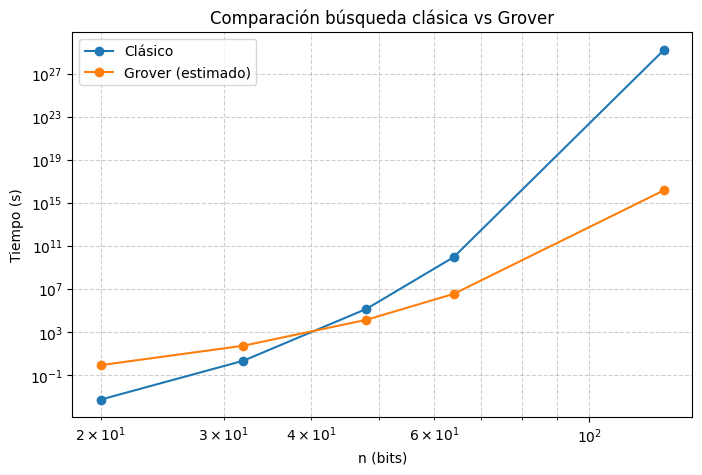

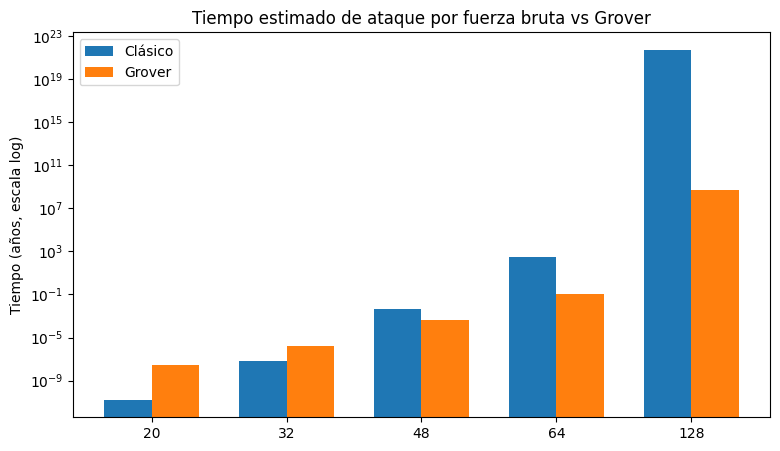

In [ ]:
# ---------- Ejemplo de uso con gráficas ----------
if __name__ == "__main__":
    n_small = 6
    target = 19
    res = run_grover_and_time(n_small, target)

    print("Iteraciones:", res['iters'])
    print("Transpile time:", res['transpile_time'], "s")
    print("Exec time:", res['exec_time'], "s")
    print("t_oracle_by_time:", res['t_oracle_by_time'], "s")

    counts = res['counts']

    # --- 1) Histograma de resultados ---
    plot_histogram(counts).show()

    # --- 2) Curva comparativa log-log ---
    ns = [20, 32, 48, 64, 128]
    T_cl = [time_classic(n) for n in ns]
    T_q = [time_grover_theoretical(n, res['t_oracle_by_time']) for n in ns]

    plt.figure(figsize=(8,5))
    plt.loglog(ns, T_cl, 'o-', label="Clásico")
    plt.loglog(ns, T_q, 'o-', label="Grover (estimado)")
    plt.xlabel("n (bits)")
    plt.ylabel("Tiempo (s)")
    plt.title("Comparación búsqueda clásica vs Grover")
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend()
    plt.show()

    # --- 3) Barplot en años ---
    years_cl = np.array(T_cl) / (3600*24*365)
    years_q = [t/(3600*24*365) if t else None for t in T_q]

    x = np.arange(len(ns))
    width = 0.35
    plt.figure(figsize=(9,5))
    plt.bar(x - width/2, years_cl, width, label="Clásico")
    plt.bar(x + width/2, [y if y else 0 for y in years_q], width, label="Grover")
    plt.xticks(x, ns)
    plt.yscale("log")
    plt.ylabel("Tiempo (años, escala log)")
    plt.title("Tiempo estimado de ataque por fuerza bruta vs Grover")
    plt.legend()
    plt.show()